In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time

from nodes import *
from model import Model
from scaler import Scaler
from utils import *
from optimizer import Optimizer

In [2]:
scaler = Scaler()
X, Y, y = load_training_batches()
X_train, Y_train, y_train = X[:, :49000], Y[:, :49000], y[:49000]
X_val, Y_val, y_val = X[:, 49000:], Y[:,49000:], y[49000:]
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test, Y_test, y_test = load_batch('test_batch')
X_test = scaler.transform(X_test)
f = 4
nf = 80
Mx_train = precompute_Mx(X_train, f)
Mx_train_flipped = precompute_Mx(flip_vertically(X_train),f)
Mx_val = precompute_Mx(X_val, f)
Mx_test = precompute_Mx(X_test, f)

/home/josef/Uni/P4/deep_learning/DD2424-assignments/assignment3/src/utils.py:20: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


In [3]:
model = Model(f, nf, 600, 10, p = 0.3)
optimizer = Optimizer(model, CrossEntropyLoss(), lr=0.001, reg=0.002, label_smoothing=0.1, lr_decay=0.9)
optimizer.train_with_cyclical_lr(Mx_train, y_train, Mx_val, y_val, lr_min=1e-5, lr_max=1e-1, step_size=800, n_cycles=5, batch_size=100, print_every=800, flip_prob=0.5, Mx_train_flip=Mx_train_flipped)

Update step 800 - Train Loss: 1.5790, Val Loss: 1.4213, Train Acc: 0.5287, Val Acc: 0.5250, LR: 0.099875
Update step 1600 - Train Loss: 1.4128, Val Loss: 1.2264, Train Acc: 0.6184, Val Acc: 0.5820, LR: 0.000135
Update step 2400 - Train Loss: 1.4007, Val Loss: 1.2227, Train Acc: 0.6253, Val Acc: 0.5980, LR: 0.044949
Update step 3200 - Train Loss: 1.3668, Val Loss: 1.1763, Train Acc: 0.6346, Val Acc: 0.6020, LR: 0.089944
Update step 4000 - Train Loss: 1.2795, Val Loss: 1.0952, Train Acc: 0.6839, Val Acc: 0.6530, LR: 0.045061
Update step 4800 - Train Loss: 1.2303, Val Loss: 1.0530, Train Acc: 0.7126, Val Acc: 0.6590, LR: 0.000066
Update step 5600 - Train Loss: 1.2303, Val Loss: 1.0530, Train Acc: 0.7126, Val Acc: 0.6590, LR: 0.020232
Update step 6400 - Train Loss: 1.2246, Val Loss: 1.0547, Train Acc: 0.7119, Val Acc: 0.6420, LR: 0.040480
Update step 7200 - Train Loss: 1.2246, Val Loss: 1.0547, Train Acc: 0.7119, Val Acc: 0.6420, LR: 0.060727
Update step 8000 - Train Loss: 1.2509, Val Loss

In [6]:
optimizer.set_eval_mode()
test_acc = optimizer.compute_accuracy(Mx_test, y_test)
val_acc = optimizer.compute_accuracy(Mx_val, y_val) 
print(f"Test accuracy: {test_acc:.4f}, Validation accuracy: {val_acc:.4f}")

Test accuracy: 0.7197, Validation accuracy: 0.7200


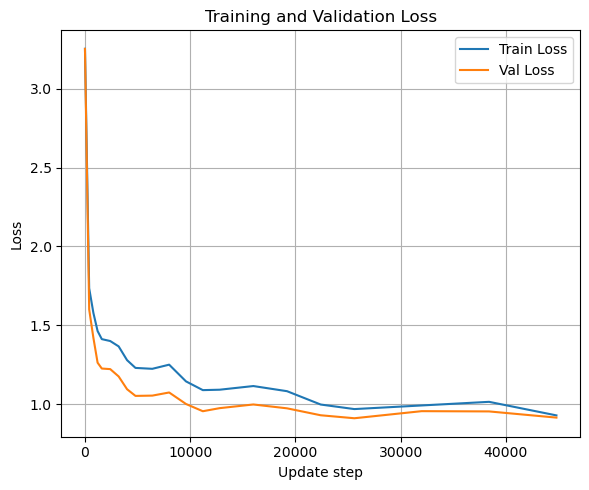

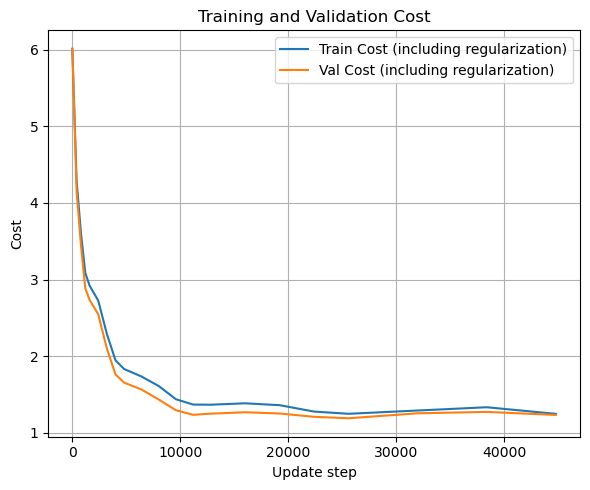

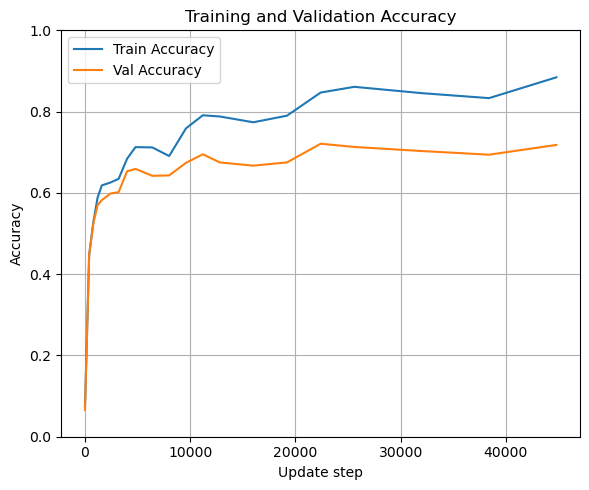

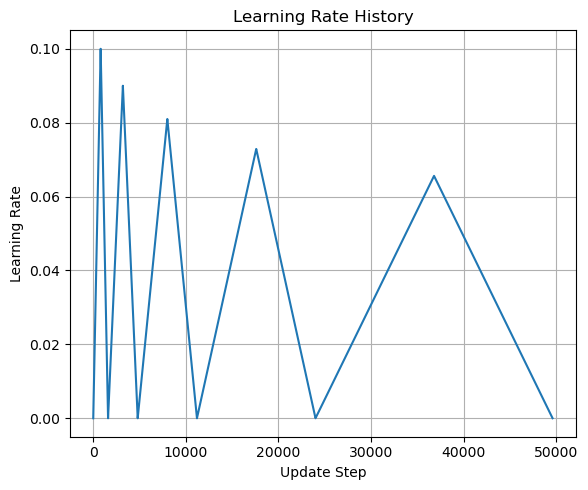

In [5]:
optimizer.plot_cyclical_lr_training_progress()
optimizer.plot_learning_rate_history()